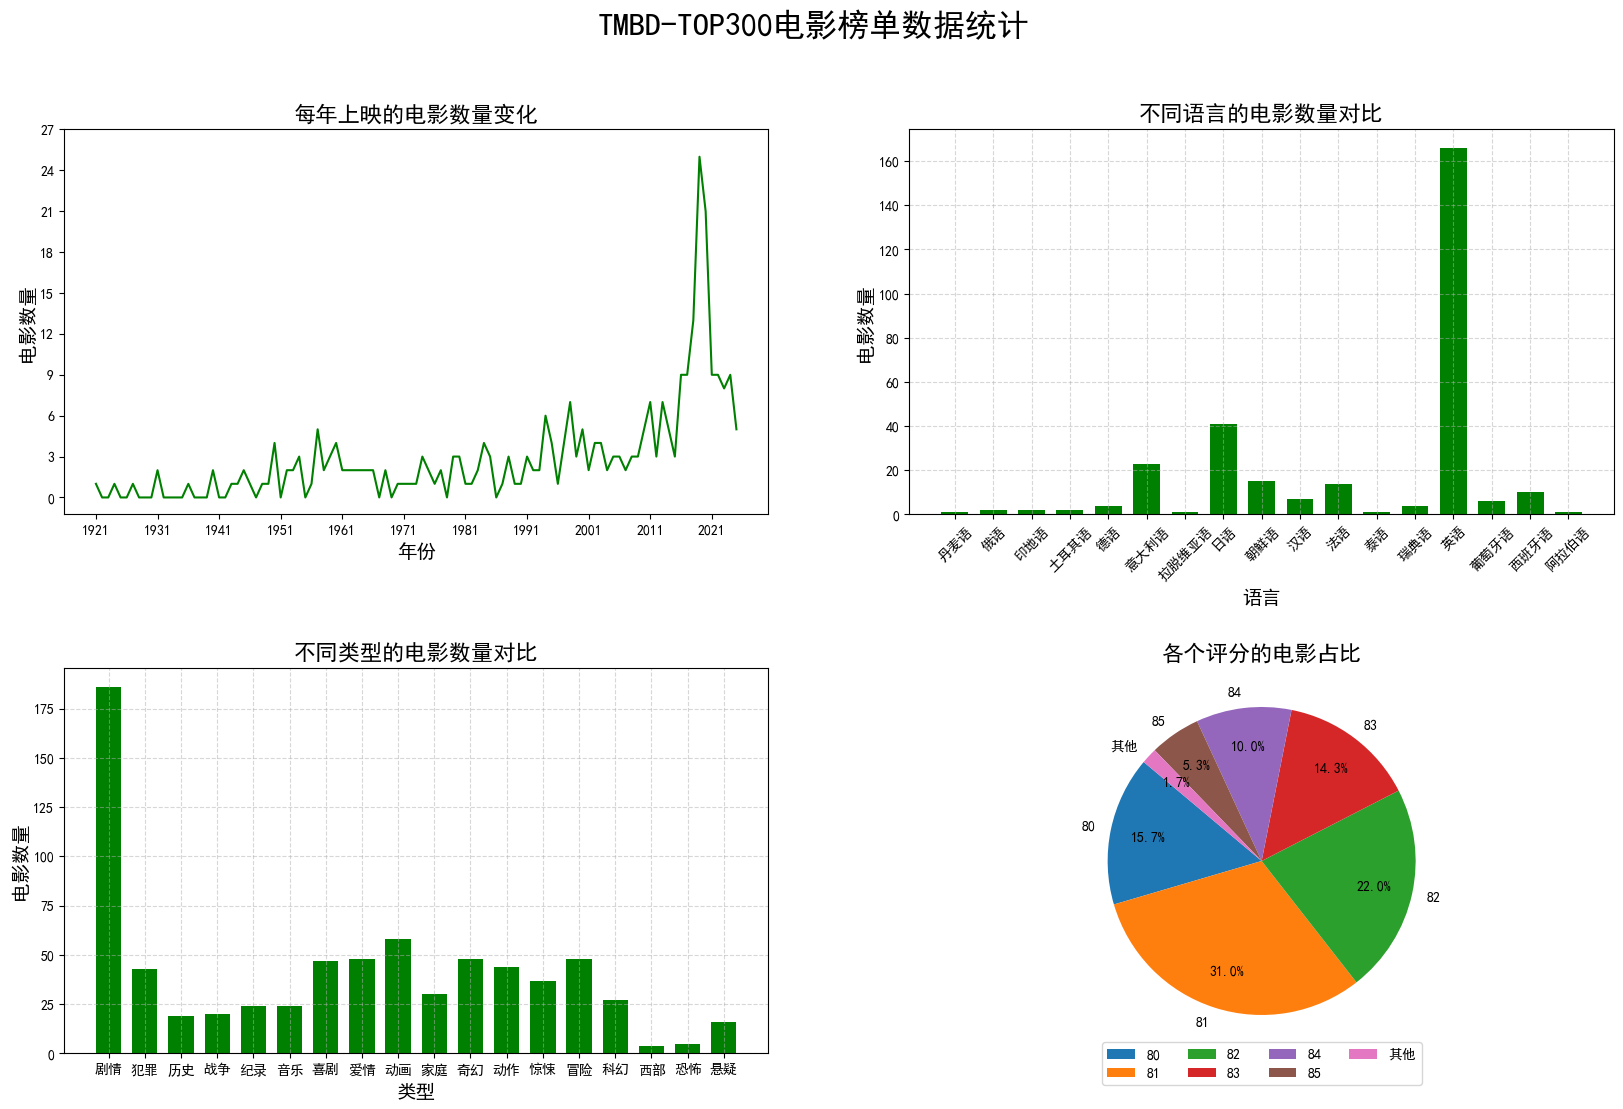

In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes

plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体

# 创建子图
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), dpi=100)
fig.suptitle('TMBD-TOP300电影榜单数据统计', fontsize=23) # 添加画布标题
# 调整子图之间的间距，wspace为水平间距，hspace为垂直间距
fig.subplots_adjust(wspace=0.2, hspace=0.4) 

# 获取子图
axes1: Axes = axes[0][0]
axes2: Axes = axes[0][1]
axes3: Axes = axes[1][0]
axes4: Axes = axes[1][1]

# 加载数据
# int64 不支持空值
# Int64 支持空值
# float64 支持空值
data = pd.read_csv('data/movies.csv', usecols=['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言'], dtype={'年份': 'Int64'})

# 1. 统计每一年上映的电影数量的变化 (折线图)
# 1.1 缺失值,异常值处理
# print(data.isnull().sum())
data['年份']= data['年份'].fillna(data['上映时间'].str[:4])

# 1.2 分组统计
year_count = data.groupby('年份')['年份'].count()

# 1.3 组装数据
# x轴
min_year = year_count.index.min()
max_year = year_count.index.max()
x_year = [i for i in range(min_year, max_year+1)]
# y轴
y_year = [year_count.get(i, 0) for i in x_year] # get(i, 0)表示如果i在year_count中则返回year_count[i]，否则返回0

# 1.4 绘制折线图
axes1.plot(x_year, y_year, color='green')
axes1.set_title('每年上映的电影数量变化', fontsize=16)
axes1.set_xlabel('年份', fontsize=14)
axes1.set_ylabel('电影数量', fontsize=14)

axes1.set_xticks(x_year[::10]) # 设置x轴刻度
y_ticks = [i for i in range(0, max(y_year)+3, 3)] # 设置y轴刻度
axes1.set_yticks(y_ticks)


# 2. 统计对比不同语言的电影数量 (柱状图)
# 2.1 缺失值,异常值处理 - 无
# 2.2 分组统计
language_count = data.groupby('语言')['语言'].count()

# 2.3 组装数据
# x = [i for i in language_count.index] # x轴
# y = [i for i in language_count.values] # y轴
x_language = language_count.index.tolist()
y_language = language_count.values.tolist()


# 2.4 绘制柱状图
axes2.bar(x_language, y_language, color='g', width=0.7)
axes2.set_title('不同语言的电影数量对比', fontsize=16)
axes2.set_xlabel('语言', fontsize=14)
axes2.set_ylabel('电影数量', fontsize=14)
axes2.tick_params(axis='x', rotation=45) # 旋转x轴刻度
axes2.grid(linestyle='--', alpha=0.5) # 添加网格


# 3.统计不同类型电影数量 (柱状图)
# 3.1 缺失值, 异常值处理 - 无

# 3.2 分组统计
type_count = {}
for type_list in data['类型'].str.split(','):
    for type in type_list:
        if type in type_count:
            type_count[type] += 1
        else:
            type_count[type] = 1
x_type = list(type_count.keys()) # x轴
y_type = list(type_count.values()) # y轴

# 3.3 绘制柱状图
axes3.bar(x_type, y_type, color='g', width=0.7)
axes3.set_title('不同类型的电影数量对比', fontsize=16)
axes3.set_xlabel('类型', fontsize=14)
axes3.set_ylabel('电影数量', fontsize=14)
axes3.grid(linestyle='--', alpha=0.5) # 添加网格


# 4. 统计对比各个评分的电影占比 (饼状图)
# 4.1 缺失值, 异常值处理 - 无
# 4.2 分组统计
score_count = data.groupby('评分')['评分'].count()

# 合并小数据
total = score_count.sum()
large_scores = score_count[score_count >= total * 0.02] # 大数据, 比例大于等于2%
small_scores = score_count[score_count < total * 0.02] # 小数据, 比例小于2%
# shape()表示矩阵的行数和列数 shape[0]表示行数 shape[1]表示列数
if small_scores.shape[0] > 0:
    large_scores['其他'] = small_scores.sum()

scores = large_scores.index.tolist() # 评分列表
scores_values = large_scores.values.tolist() # 评分数量列表

# 4.3 绘制饼状图
# startangle=140表示从140度开始绘制 autopct='%1.1f%%'表示显示百分比 pctdistance=0.75表示scores_values与圆心的距离
axes4.pie(scores_values, labels=scores, autopct='%1.1f%%', pctdistance=0.75, startangle=140)
axes4.set_title('各个评分的电影占比', fontsize=16)
axes4.legend(loc='lower center', ncol=4, bbox_to_anchor=(0.5, -0.1))


# 5. 保存图片
plt.savefig('data/TMDB-TOP300.png')

# 显示图表
plt.show()